## Austin Transit Accessibility Project
This project examines the relationship between public transit accessibility and median household income across census tracts in Travis County, Texas. Using CapMetro transit data, GTFS service frequency, U.S. Census tract boundaries, and ACS income data, the analysis measures transit accessibility based on nearby stops and service frequency, then evaluates its relationship with household income using regression analysis and spatial visualization.

### Data Cleaning

In [1]:
import os
import pandas as pd
import geopandas as gpd

In [2]:
# Get the current working directory
base_dir = os.getcwd()
print(base_dir)

C:\Users\HRW\Desktop\Austin_Transit_Accessibility


In [3]:
# Define output folders
clean_dir = os.path.join(base_dir, "Cleaned_Data")
os.makedirs(clean_dir, exist_ok=True)

In [4]:
# Clean CapMetro Stops shapefile
stops = gpd.read_file("Stops.shp")
print("Original columns:", list(stops.columns))
print("Original record count:", len(stops))

Original columns: ['STOP_ID', 'BENCHES', 'SHELTERS', 'BIKERACKS', 'TRASHCANS', 'STOP_NAME', 'STOP_ABBR', 'STREET_NMB', 'ON_STREET', 'AT_STREET', 'CITY', 'ZIP', 'BAY', 'STOP_TYPE', 'PLACEMENT', 'CORNER', 'STATUS', 'LATITUDE', 'LONGITUDE', 'SOURCE', 'SOURCEDATE', 'geometry']
Original record count: 2348


In [5]:
# Keep useful columns
stops = stops[["STOP_ID", "STOP_NAME", "geometry"]]
# Drop rows with missing or duplicate stop_id
stops = stops.dropna(subset=["STOP_ID", "geometry"]).drop_duplicates("STOP_ID")
# Reproject to WGS84
stops = stops.to_crs(epsg=4326)
# Show sample records
display(stops.head())

,STOP_ID,STOP_NAME,geometry
0,5305,3301 Wells Branch/Howard,POINT (-97.69527 30.4401)
1,5302,TECH RIDGE BAY F,POINT (-97.66907 30.41832)
2,5279,TECH RIDGE BAY J,POINT (-97.668 30.41816)
3,5191,MONTOPOLIS/CADDIE,POINT (-97.70201 30.22735)
4,243,RIO GRANDE/15TH,POINT (-97.74634 30.27897)


In [6]:
# Save cleaned data
stops_clean_path = os.path.join(clean_dir, "capmetro_stops_clean.shp")
stops.to_file(stops_clean_path)
print("Cleaned stops saved to:", stops_clean_path)

Cleaned stops saved to: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\Cleaned_Data\capmetro_stops_clean.shp


In [7]:
# Clean Census Tract shapefile
# Load the Texas state-level tracts file
tracts_tx = gpd.read_file("tl_2025_48_tract.shp")
# Check available columns
print(tracts_tx.columns)

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='object')


In [8]:
# Filter for Travis County
tracts = tracts_tx[tracts_tx["COUNTYFP"] == "453"]

In [9]:
print("Original columns:", list(tracts.columns))
print("Original tract count:", len(tracts))

Original columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
Original tract count: 290


In [10]:
# Keep only necessary fields
tracts = tracts[["GEOID", "NAMELSAD", "geometry"]].drop_duplicates("GEOID")
# Reproject to WGS84
tracts = tracts.to_crs(epsg=4326)
# Show sample records
display(tracts.head())

,GEOID,NAMELSAD,geometry
216,48453002112,Census Tract 21.12,"POLYGON ((-97.69126 30.31622, -97.69081 30.316..."
217,48453002113,Census Tract 21.13,"POLYGON ((-97.68159 30.31607, -97.68158 30.316..."
218,48453002201,Census Tract 22.01,"POLYGON ((-97.67323 30.32572, -97.67292 30.325..."
699,48453041300,Census Tract 413,"POLYGON ((-97.73015 30.42597, -97.73007 30.426..."
721,48453035300,Census Tract 353,"POLYGON ((-98.12799 30.42262, -98.12556 30.426..."


In [11]:
# Save cleaned data
tracts_clean_path = os.path.join(clean_dir, "tracts_travis_clean.shp")
tracts.to_file(tracts_clean_path)
print("Cleaned tracts saved to:", tracts_clean_path)

Cleaned tracts saved to: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\Cleaned_Data\tracts_travis_clean.shp


In [12]:
# Clean ACS 5-Year Income Data
acs = pd.read_csv("ACSDT5Y2023.B19013-Data.csv")
print("Original columns:", list(acs.columns))
print("Original row count:", len(acs))

Original columns: ['GEO_ID', 'NAME', 'B19013_001E', 'B19013_001M', 'Unnamed: 4']
Original row count: 292


In [13]:
# Keep and rename relevant columns
acs_clean = acs[["GEO_ID", "NAME", "B19013_001E"]].rename(
    columns={"GEO_ID": "GEOID", "B19013_001E": "median_income"})

In [14]:
# Extract the 11-digit GEOID
acs_clean["GEOID"] = acs_clean["GEOID"].astype(str).str.extract(r"(\d{11})")

In [15]:
# Convert everything to a string then clean
acs_clean["median_income"] = (
    acs_clean["median_income"]
    .astype(str)
    .str.strip() 
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("−", "-", regex=False)
    .str.replace("--", "", regex=False)
    .str.replace("-", "", regex=False)
)
# Convert cleaned values to numeric
acs_clean["median_income"] = pd.to_numeric(
    acs_clean["median_income"], errors="coerce"
)
# Remove missing or zero values
acs_clean = acs_clean.dropna(subset=["median_income", "GEOID"])
acs_clean = acs_clean[acs_clean["median_income"] > 0]

In [16]:
# Show preview
display(acs_clean.head())

,GEOID,NAME,median_income
2,48453000101,Census Tract 1.01; Travis County; Texas,123050.0
3,48453000102,Census Tract 1.02; Travis County; Texas,155897.0
4,48453000203,Census Tract 2.03; Travis County; Texas,95778.0
5,48453000204,Census Tract 2.04; Travis County; Texas,120464.0
6,48453000205,Census Tract 2.05; Travis County; Texas,78287.0


In [17]:
# Save cleaned CSV
acs_clean_path = os.path.join(clean_dir, "travis_income_clean.csv")
acs_clean.to_csv(acs_clean_path, index=False)
print("Cleaned ACS data saved to:", acs_clean_path)

Cleaned ACS data saved to: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\Cleaned_Data\travis_income_clean.csv


In [18]:
# Load GTFS stops.txt
stops = pd.read_csv("stops.txt")
# Load GTFS stop_times.txt
stop_times = pd.read_csv("stop_times.txt")

In [19]:
# Count how many times each stop_id appears to calculate service_score
service_freq = (
    stop_times.groupby("stop_id")
    .size()
    .reset_index(name="service_score"))

In [20]:
# Merge service scores back to stops
stops_clean = stops.merge(service_freq, on="stop_id", how="left")

In [21]:
# If no service score put 0
stops_clean["service_score"] = stops_clean["service_score"].fillna(0)

In [22]:
# Convert stops into GeoDataFrame
stops_gdf = gpd.GeoDataFrame(
    stops_clean,
    geometry=gpd.points_from_xy(stops_clean["stop_lon"], stops_clean["stop_lat"]),
    crs="EPSG:4326")

In [23]:
stops_clean.head()

,stop_id,at_street,corner_placement,heading,location_type,on_street,parent_station,stop_code,stop_desc,stop_lat,stop_lon,stop_name,stop_position,stop_timezone,stop_url,wheelchair_boarding,zone_id,service_score
0,1002,Burton,SW,144.0,0,Riverside,NaN,1002,002021 Riverside & Burton,30.240341,-97.727308,Riverside/Burton,N,NaN,https://www.capmetro.org/stopdetail/index.php?...,0,NaN,843.0
1,1003,Willow Creek,NW,162.0,0,Riverside,NaN,1003,002237 Riverside & Willow Creek,30.238275,-97.726015,2237 Riverside/Willow Creek,M,NaN,https://www.capmetro.org/stopdetail/index.php?...,0,NaN,578.0
2,1005,Pleasant Valley,SW,144.0,0,Riverside,NaN,1005,002507 Riverside & Pleasant Valley,30.233867,-97.723760,2507 Riverside/Pleasant Valley,N,NaN,https://www.capmetro.org/stopdetail/index.php?...,0,NaN,578.0
3,1008,Huntwick,SW,118.0,0,Oltorf,NaN,1008,004411 Oltorf & Huntwick,30.226619,-97.726260,4411 Oltorf/Huntwick,N,NaN,https://www.capmetro.org/stopdetail/index.php?...,0,NaN,315.0
4,1009,Oltorf,NE,67.0,0,Wickersham,NaN,1009,002401 Wickersham & Oltorf,30.226039,-97.723488,2401 Wickersham/Oltorf,M,NaN,https://www.capmetro.org/stopdetail/index.php?...,0,NaN,268.0


In [24]:
# Select only useful columns
stops_clean = stops_clean[[
    "stop_id",
    "stop_name",
    "stop_lat",
    "stop_lon",
    "service_score"
]]

In [25]:
stops_clean.head()

,stop_id,stop_name,stop_lat,stop_lon,service_score
0,1002,Riverside/Burton,30.240341,-97.727308,843.0
1,1003,2237 Riverside/Willow Creek,30.238275,-97.726015,578.0
2,1005,2507 Riverside/Pleasant Valley,30.233867,-97.723760,578.0
3,1008,4411 Oltorf/Huntwick,30.226619,-97.726260,315.0
4,1009,2401 Wickersham/Oltorf,30.226039,-97.723488,268.0


In [26]:
# Save cleaned GTFS data
output_path = os.path.join(clean_dir, "gtfs_stops_clean.csv")
stops_clean.to_csv(output_path, index=False)
print("Saved cleaned GTFS stops to:", output_path)

Saved cleaned GTFS stops to: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\Cleaned_Data\gtfs_stops_clean.csv


### Spatial Analysis

In [29]:
import arcpy
from arcpy import env
import numpy as np
import statsmodels.api as sm

In [30]:
# set path
output_folder = os.path.join(base_dir, "ProjectFile")
os.makedirs(output_folder, exist_ok = True)

capmetro = os.path.join(clean_dir, "capmetro_stops_clean.shp")
gtfs = os.path.join(clean_dir, "gtfs_stops_clean.csv")
tracts = os.path.join(clean_dir, "tracts_travis_clean.shp")
acs = os.path.join(clean_dir, "travis_income_clean.csv")

# allow overwrite
env.overwriteOutput = True

In [31]:
# 1. mark the 'frequent stop' in the GTFS table

# read gtfs csv file
gtfs_df = pd.read_csv(gtfs)

# set the service frequency threshold 
freq_threshold = gtfs_df["service_score"].quantile(0.75)
print("Frequent stop threshold (service_score >=):", freq_threshold)

# create a binary flag: 1 = frequent, 0 = non-frequent
gtfs_df["freq_stop"] = (gtfs_df["service_score"] >= freq_threshold).astype(int)

# save as new csv file
gtfs_freq_csv = os.path.join(output_folder, "gtfs_stops_with_freq.csv")
gtfs_df.to_csv(gtfs_freq_csv, index=False)
print("Saved GTFS with freq flag:", gtfs_freq_csv)

Frequent stop threshold (service_score >=): 396.0
Saved GTFS with freq flag: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\ProjectFile\gtfs_stops_with_freq.csv


In [32]:
# 2. Join service_score and freq_stop back to the bus stop shapefile

# read cleaned stop shapefile
stops_gdf = gpd.read_file(capmetro)

# make sure the stop ID field names match
if "stop_id" in gtfs_df.columns:
    gtfs_df = gtfs_df.rename(columns={"stop_id": "STOP_ID"})

# keep only the columns we need from GTFS
gtfs_keep = gtfs_df[["STOP_ID", "service_score", "freq_stop"]]

# merge GTFS attributes onto the stop points
stops_merged = stops_gdf.merge(gtfs_keep, on="STOP_ID", how="left")

# save a new stop shapefile with service_score and freq_stop
stops_with_attr = os.path.join(output_folder, "capmetro_stops_access.shp")
stops_merged.to_file(stops_with_attr)

print("Saved stops_with_attr with GTFS fields:", stops_with_attr)
print(stops_merged[["STOP_ID", "service_score", "freq_stop"]].head())

# check fields name
print("\nFields in stops_with_attr after join:")
for f in arcpy.ListFields(stops_with_attr):
    print(" -", f.name)

C:\Users\HRW\AppData\Local\Temp\ipykernel_2292\1749354032.py:18: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  stops_merged.to_file(stops_with_attr)
C:\Users\HRW\AppData\Roaming\Python\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'service_score' to 'service_sc'
  ogr_write(


Saved stops_with_attr with GTFS fields: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\ProjectFile\capmetro_stops_access.shp
   STOP_ID  service_score  freq_stop
0     5305           98.0        0.0
1     5302          272.0        0.0
2     5279           24.0        0.0
3     5191          346.0        0.0
4      243          284.0        0.0

Fields in stops_with_attr after join:
 - FID
 - Shape
 - STOP_ID
 - STOP_NAME
 - service_sc
 - freq_stop


In [33]:
# 3. Create 800 meters buffer around each bus stop

stops_buffer = os.path.join(output_folder, "stops_800m.shp")
arcpy.analysis.Buffer(stops_with_attr, stops_buffer, "800 Meters", "FULL", "ROUND", "NONE")

print("Buffer created:", stops_buffer)

# check fields name
print("\nFields in stops_with_attr after join:")
for f in arcpy.ListFields(stops_buffer):
    print(" -", f.name)

Buffer created: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\ProjectFile\stops_800m.shp

Fields in stops_with_attr after join:
 - FID
 - Shape
 - STOP_ID
 - STOP_NAME
 - service_sc
 - freq_stop
 - BUFF_DIST
 - ORIG_FID


In [34]:
# 4. Spatial join tracts and buffers

tract_stop_join = os.path.join(output_folder, "tracts_stop_join.shp")

# for each tract create one record for every stop buffer that intersects it
# create a table with tract and stop pairs with service_score and freq_stop
arcpy.analysis.SpatialJoin(
    target_features=tracts,
    join_features=stops_buffer,
    out_feature_class=tract_stop_join,
    join_operation="JOIN_ONE_TO_MANY",
    join_type="KEEP_ALL",
    match_option="INTERSECT"
)

print("Tract-stop join shapefile:", tract_stop_join)

# check fields name
print("\nFields in stops_with_attr after join:")
for f in arcpy.ListFields(tract_stop_join):
    print(" -", f.name)

Tract-stop join shapefile: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\ProjectFile\tracts_stop_join.shp

Fields in stops_with_attr after join:
 - FID
 - Shape
 - Join_Count
 - TARGET_FID
 - JOIN_FID
 - GEOID
 - NAMELSAD
 - STOP_ID
 - STOP_NAME
 - service_sc
 - freq_stop
 - BUFF_DIST
 - ORIG_FID


In [35]:
# 5. Aggregate to tract level with accessibility level calculation

geoid_field = "GEOID"
service_field = "service_sc"

stats_table = os.path.join(output_folder, "tracts_access_stats.dbf")

arcpy.analysis.Statistics(
    in_table=tract_stop_join,
    out_table=stats_table,
    statistics_fields=[
        ["STOP_ID", "COUNT"], # total number of reachable stops
        ["freq_stop", "SUM"], # number of frequent stops
        [service_field, "SUM"]], # sum of service_score = weighted index
    case_field=geoid_field)

print("Created stats table:", stats_table)

# check fields name
print("\nFields in stops_with_attr after join:")
for f in arcpy.ListFields(stats_table):
    print(" -", f.name)

Created stats table: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\ProjectFile\tracts_access_stats.dbf

Fields in stops_with_attr after join:
 - OID
 - GEOID
 - FREQUENCY
 - COUNT_STOP
 - SUM_freq_s
 - SUM_servic


In [36]:
# 6. Copy original tracts to create accessibility layer
tracts_access = os.path.join(output_folder, "tracts_access_final.shp")
arcpy.conversion.FeatureClassToFeatureClass(tracts, output_folder, "tracts_access_final.shp")

# join the summary statistics back to the tract polygons
arcpy.management.JoinField(
    in_data=tracts_access,
    in_field="GEOID",
    join_table=stats_table,
    join_field="GEOID",
    fields=["COUNT_stop", "SUM_freq_s", "SUM_servic"]
)

# a. total number of reachable stops within 800m
arcpy.management.AddField(tracts_access, "TotStops", "LONG")
arcpy.management.CalculateField(tracts_access, "TotStops", "!COUNT_stop!")

# b. number of frequent service stops
arcpy.management.AddField(tracts_access, "FreqStops", "LONG")
arcpy.management.CalculateField(tracts_access, "FreqStops", "!SUM_freq_s!")

# c. weighted accessibility index
# WAccess = sum of service score of all stops in a tract
arcpy.management.AddField(tracts_access, "WAccess", "DOUBLE")
arcpy.management.CalculateField(tracts_access, "WAccess", "!SUM_servic!")

print("Final tract accessibility layer:", tracts_access)

Final tract accessibility layer: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\ProjectFile\tracts_access_final.shp


In [37]:
# 7. Join ACS median_income for OLS

# Read the final tract accessibility shapefile
tracts_gdf = gpd.read_file(tracts_access)
# Read ACS income CSV
acs_df = pd.read_csv(acs, dtype={"GEOID": str})

# Keep only the fields we need from ACS
acs_df = acs_df[["GEOID", "median_income"]]

# Merge ACS median income into the tract GeoDataFrame
tracts_acs_gdf = tracts_gdf.merge(acs_df, on="GEOID", how="left")

print("Merged GeoDataFrame:")
print(tracts_acs_gdf[["GEOID", "TotStops", "FreqStops", "WAccess", "median_income"]].head())

Merged GeoDataFrame:
         GEOID  TotStops  FreqStops  WAccess  median_income
0  48453002112        66         31  23591.0        70034.0
1  48453002113        44         23  16167.0       136587.0
2  48453002201        50         18  15115.0        74653.0
3  48453041300         7          0     56.0       104909.0
4  48453035300         1          0      0.0       133500.0


In [38]:
# save merged result as a new shapefile for mapping in ArcGIS
tracts_acs_shp = os.path.join(output_folder, "tracts_access_income.shp")
tracts_acs_gdf.to_file(tracts_acs_shp)

print("Saved merged shapefile:", tracts_acs_shp)

Saved merged shapefile: C:\Users\HRW\Desktop\Austin_Transit_Accessibility\ProjectFile\tracts_access_income.shp


C:\Users\HRW\AppData\Local\Temp\ipykernel_2292\125951663.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  tracts_acs_gdf.to_file(tracts_acs_shp)
C:\Users\HRW\AppData\Roaming\Python\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'median_income' to 'median_inc'
  ogr_write(


In [39]:
# 8. OLS regression

# convert to a regular pandas DataFrame for regression
reg_df = pd.DataFrame(tracts_acs_gdf[["median_income", "TotStops", "FreqStops", "WAccess"]])

# drop rows with missing or non-positive income
reg_df = reg_df.replace([np.inf, -np.inf], np.nan)
reg_df = reg_df.dropna(subset=["median_income", "TotStops", "FreqStops", "WAccess"])
reg_df = reg_df[reg_df["median_income"] > 0]

print("Regression data:")
print(reg_df.head())

Regression data:
   median_income  TotStops  FreqStops  WAccess
0        70034.0        66         31  23591.0
1       136587.0        44         23  16167.0
2        74653.0        50         18  15115.0
3       104909.0         7          0     56.0
4       133500.0         1          0      0.0


In [40]:
# 1). median_income ~ WAccess
X1 = sm.add_constant(reg_df["median_income"])
y1 = reg_df["WAccess"]
model1 = sm.OLS(y1, X1).fit()
print("\nModel 1: WAccess ~ median_income")
print(model1.summary())


Model 1: WAccess ~ median_income
                            OLS Regression Results                            
Dep. Variable:                WAccess   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     26.06
Date:                  周一, 07 9月 2026   Prob (F-statistic):           6.11e-07
Time:                        20:25:18   Log-Likelihood:                -3091.7
No. Observations:                 283   AIC:                             6187.
Df Residuals:                     281   BIC:                             6195.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const       

In [41]:
import matplotlib.pyplot as plt
import contextily as ctx
import folium

In [42]:
# Plotting Model 1: 

plt.style.use('_mpl-gallery')

# data
x_val = reg_df["median_income"]
y_val = reg_df["WAccess"]

In [43]:
z = np.polyfit(x_val, y_val, 1) # 1 is a straight line or 1st order polynomial
p = np.poly1d(z)

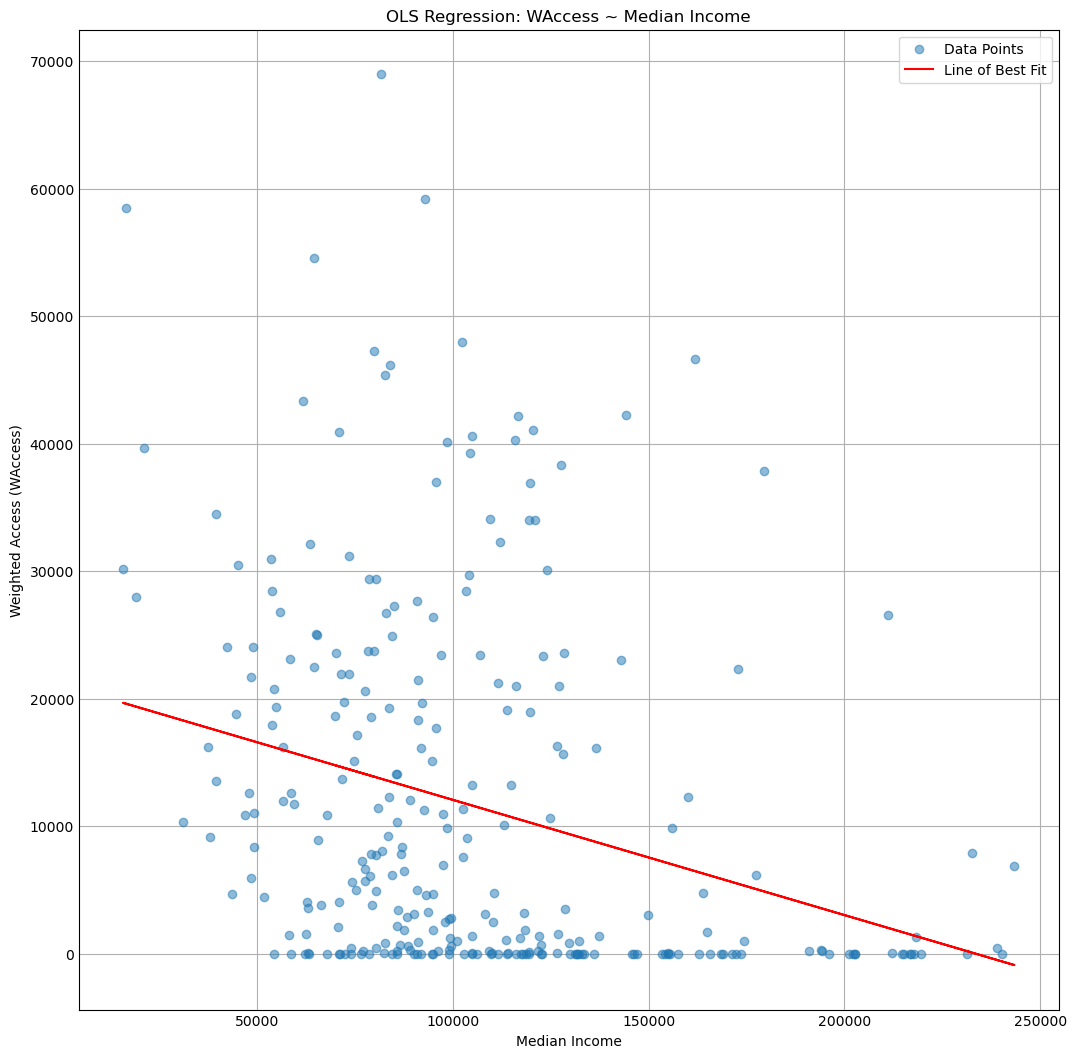

In [44]:
# Had to sort x values because it initally it produced a zig-zag dashed line
# Convert x_val to a 1d array
x1d = np.array(x_val).flatten()

# Create a best-fit y valyes from the regression equation
y_fit = p(x1d)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
plt.xlabel("Median Income")
plt.ylabel("Weighted Access (WAccess)")
plt.title("OLS Regression: WAccess ~ Median Income")

# create the scatter plot
ax.scatter(x_val, y_val, label='Data Points',alpha = 0.5)

# plot type .plot() is a line plot rather than a scatterlot
ax.plot(x_val, y_fit, color='r', label='Line of Best Fit')

ax.legend(loc="upper right")
plt.savefig("Model_1_OLS.png", dpi=300, bbox_inches='tight')
plt.show()

In [45]:
### Results for Model 1:
# Higher median income is significantly associated with lower WAccess (negative coefficient, p<0.001)
# Median income explains about 8% of the WAccess variable

In [46]:
# 2). quadratic model
# Create quadratic term
reg_df["income_sq"] = reg_df["median_income"]**2

# WAccess ~ median_income + income_sq
X_quad = reg_df[["median_income", "income_sq"]]
X_quad = sm.add_constant(X_quad)
Y_quad = reg_df["WAccess"]

model_quad = sm.OLS(Y_quad, X_quad).fit()
print("\nModel 2 (Quadratic): WAccess ~ median_income + income_sq")
print(model_quad.summary())


Model 2 (Quadratic): WAccess ~ median_income + income_sq
                            OLS Regression Results                            
Dep. Variable:                WAccess   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     13.78
Date:                  周一, 07 9月 2026   Prob (F-statistic):           1.97e-06
Time:                        20:25:25   Log-Likelihood:                -3091.0
No. Observations:                 283   AIC:                             6188.
Df Residuals:                     280   BIC:                             6199.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

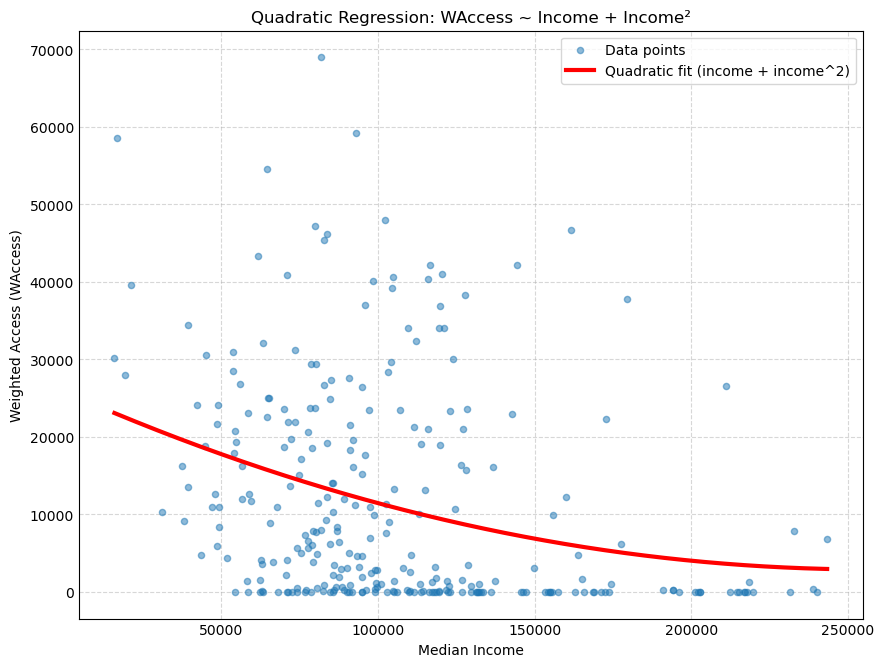

In [47]:
# Plotting Model 2:
# Prepare variables
x = reg_df["median_income"]
y = reg_df["WAccess"]

# quadratic terms
reg_df["income_sq"] = x**2

# Fit the quadratic model
X = sm.add_constant(np.column_stack([x, x**2]))
model_quad = sm.OLS(y, X).fit()

# Make prediction line
x_line = np.linspace(x.min(), x.max(), 500)
X_line = sm.add_constant(np.column_stack([x_line, x_line**2]))
y_line = model_quad.predict(X_line)

# Plot scatter and curve
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.5, s=20, label="Data points")
plt.plot(x_line, y_line, linewidth=3, color='red', label="Quadratic fit (income + income^2)")

plt.xlabel("Median Income")
plt.ylabel("Weighted Access (WAccess)")
plt.title("Quadratic Regression: WAccess ~ Income + Income²")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [48]:
### Results for Model 2:
# Higher income is still significntly associated with lower weighted transit access
# The squared income term is not significant
# so there might be other factors affecting the relationship between median income and accessibility

In [49]:
tracts = gpd.read_file(
    os.path.join(output_folder, "tracts_access_income.shp")
)

stops = gpd.read_file(
    os.path.join(clean_dir, "capmetro_stops_clean.shp")
)

buffers = gpd.read_file(
    os.path.join(output_folder, "stops_800m.shp")
)

C:\Users\HRW\AppData\Roaming\Python\Python311\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


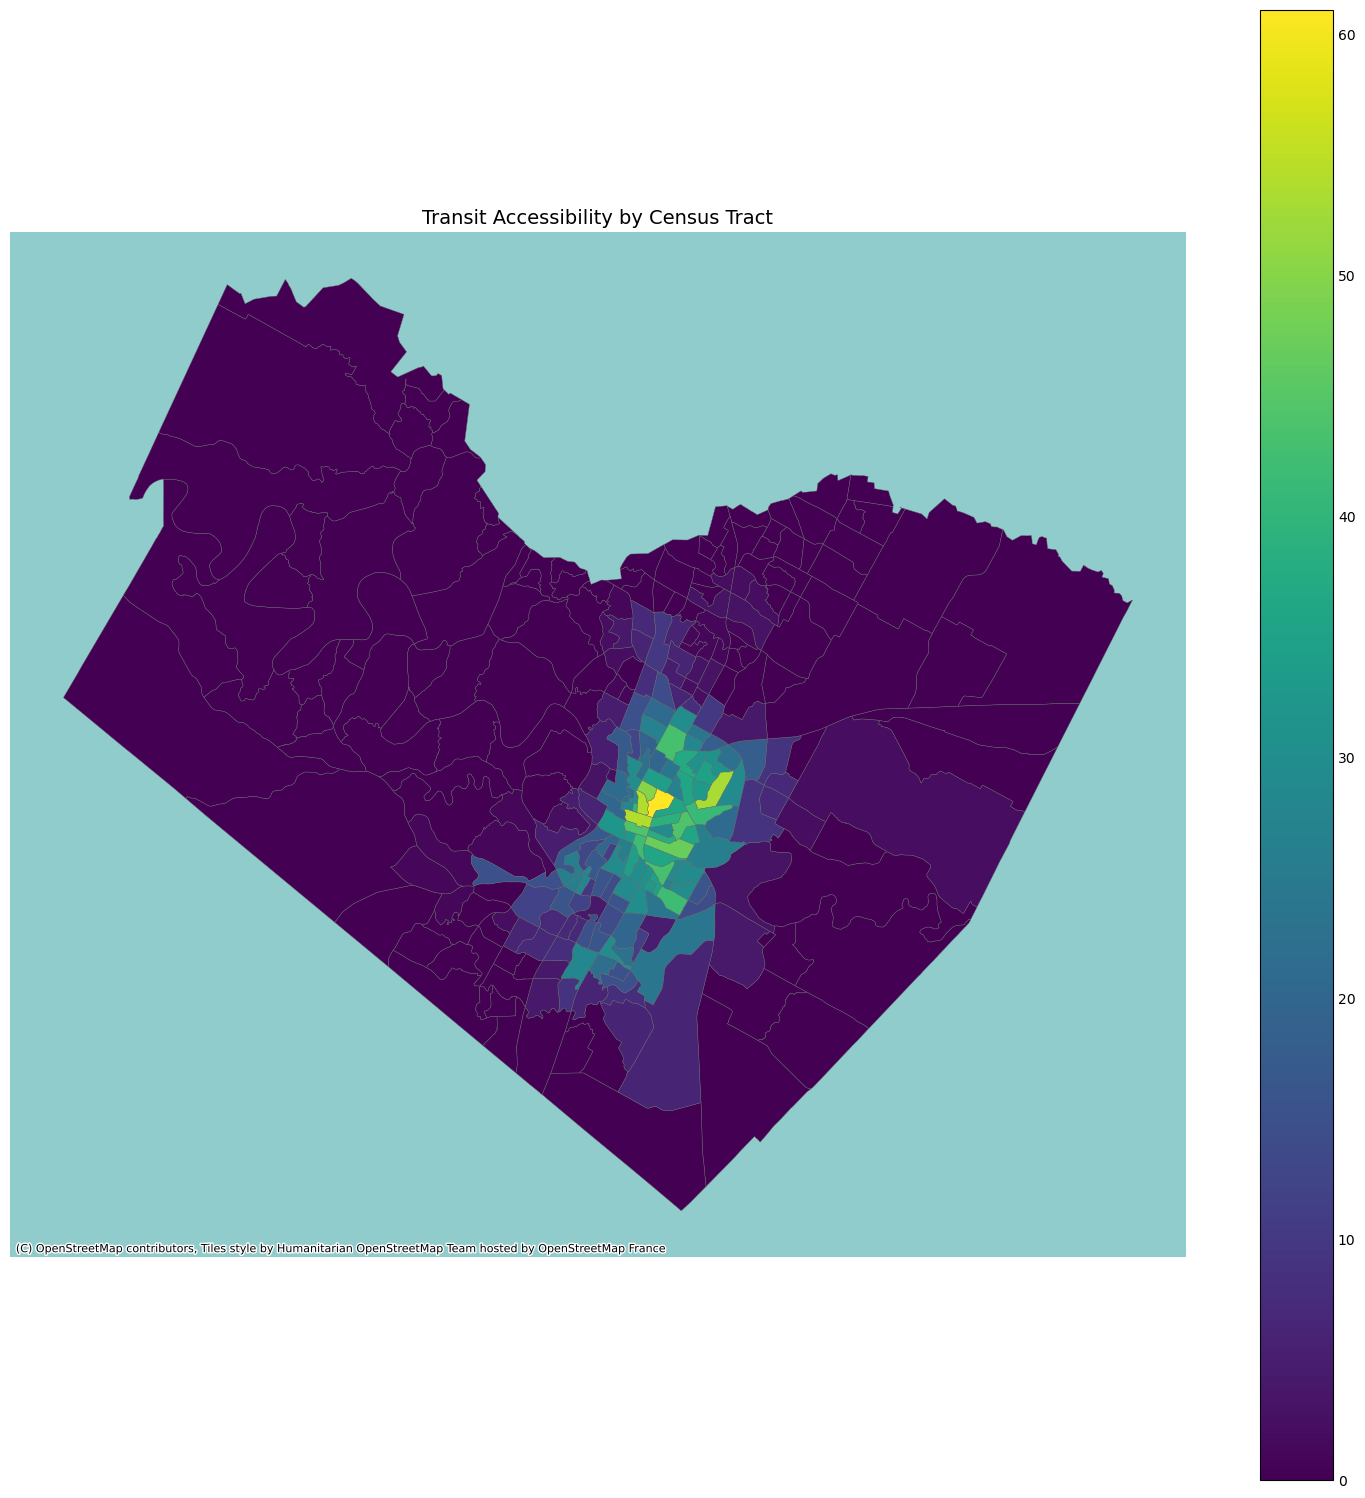

In [50]:
# Map 1: Transit Accessibility Choropleth
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

tracts.plot(
    column="FreqStops",
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="0.4",
    linewidth=0.3
)

ctx.add_basemap(ax)
ax.set_title("Transit Accessibility by Census Tract", fontsize=14)
ax.axis("off")
plt.savefig("Map1_Transit_Accessibility.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\HRW\AppData\Roaming\Python\Python311\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


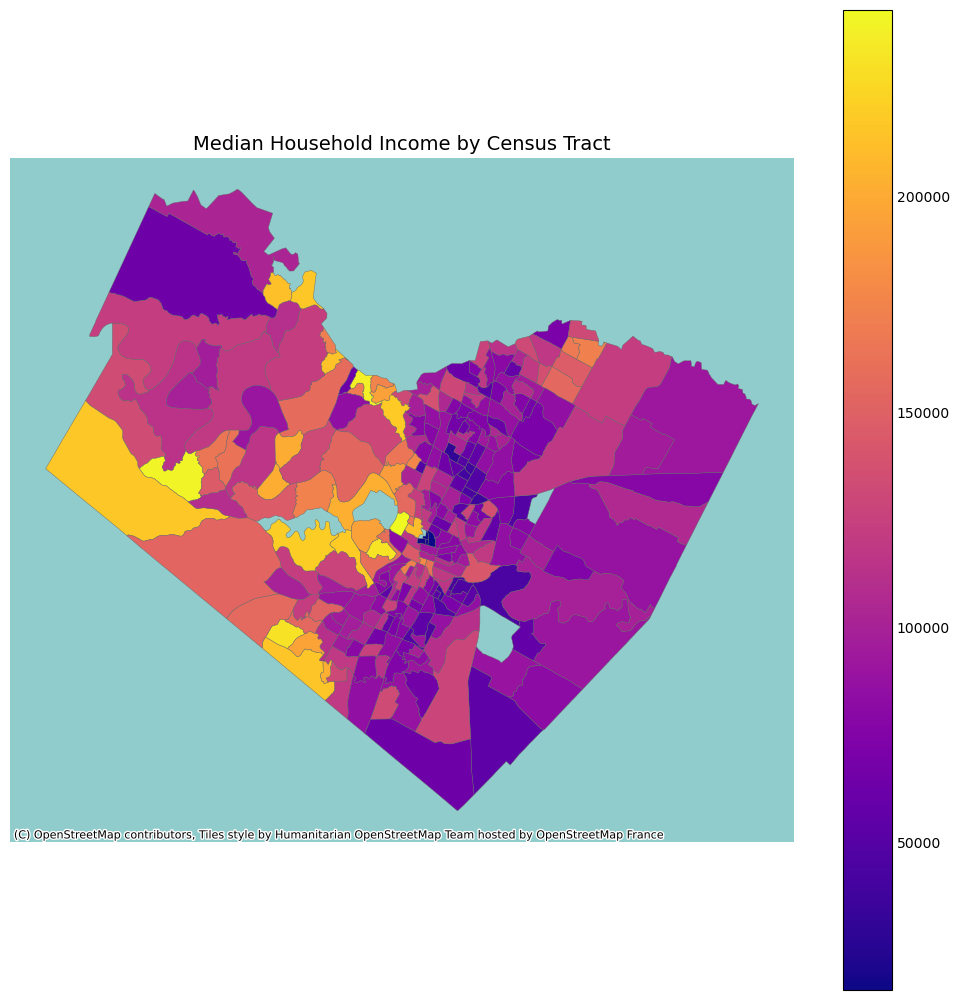

In [51]:
# Map 2: 
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

tracts.plot(
    column="median_inc",
    ax=ax,
    cmap="plasma",
    legend=True,
    edgecolor="0.4",
    linewidth=0.3
)

ctx.add_basemap(ax)
ax.set_title("Median Household Income by Census Tract", fontsize=14)
ax.axis("off")
plt.savefig("Map2_Median_Household.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\HRW\AppData\Roaming\Python\Python311\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


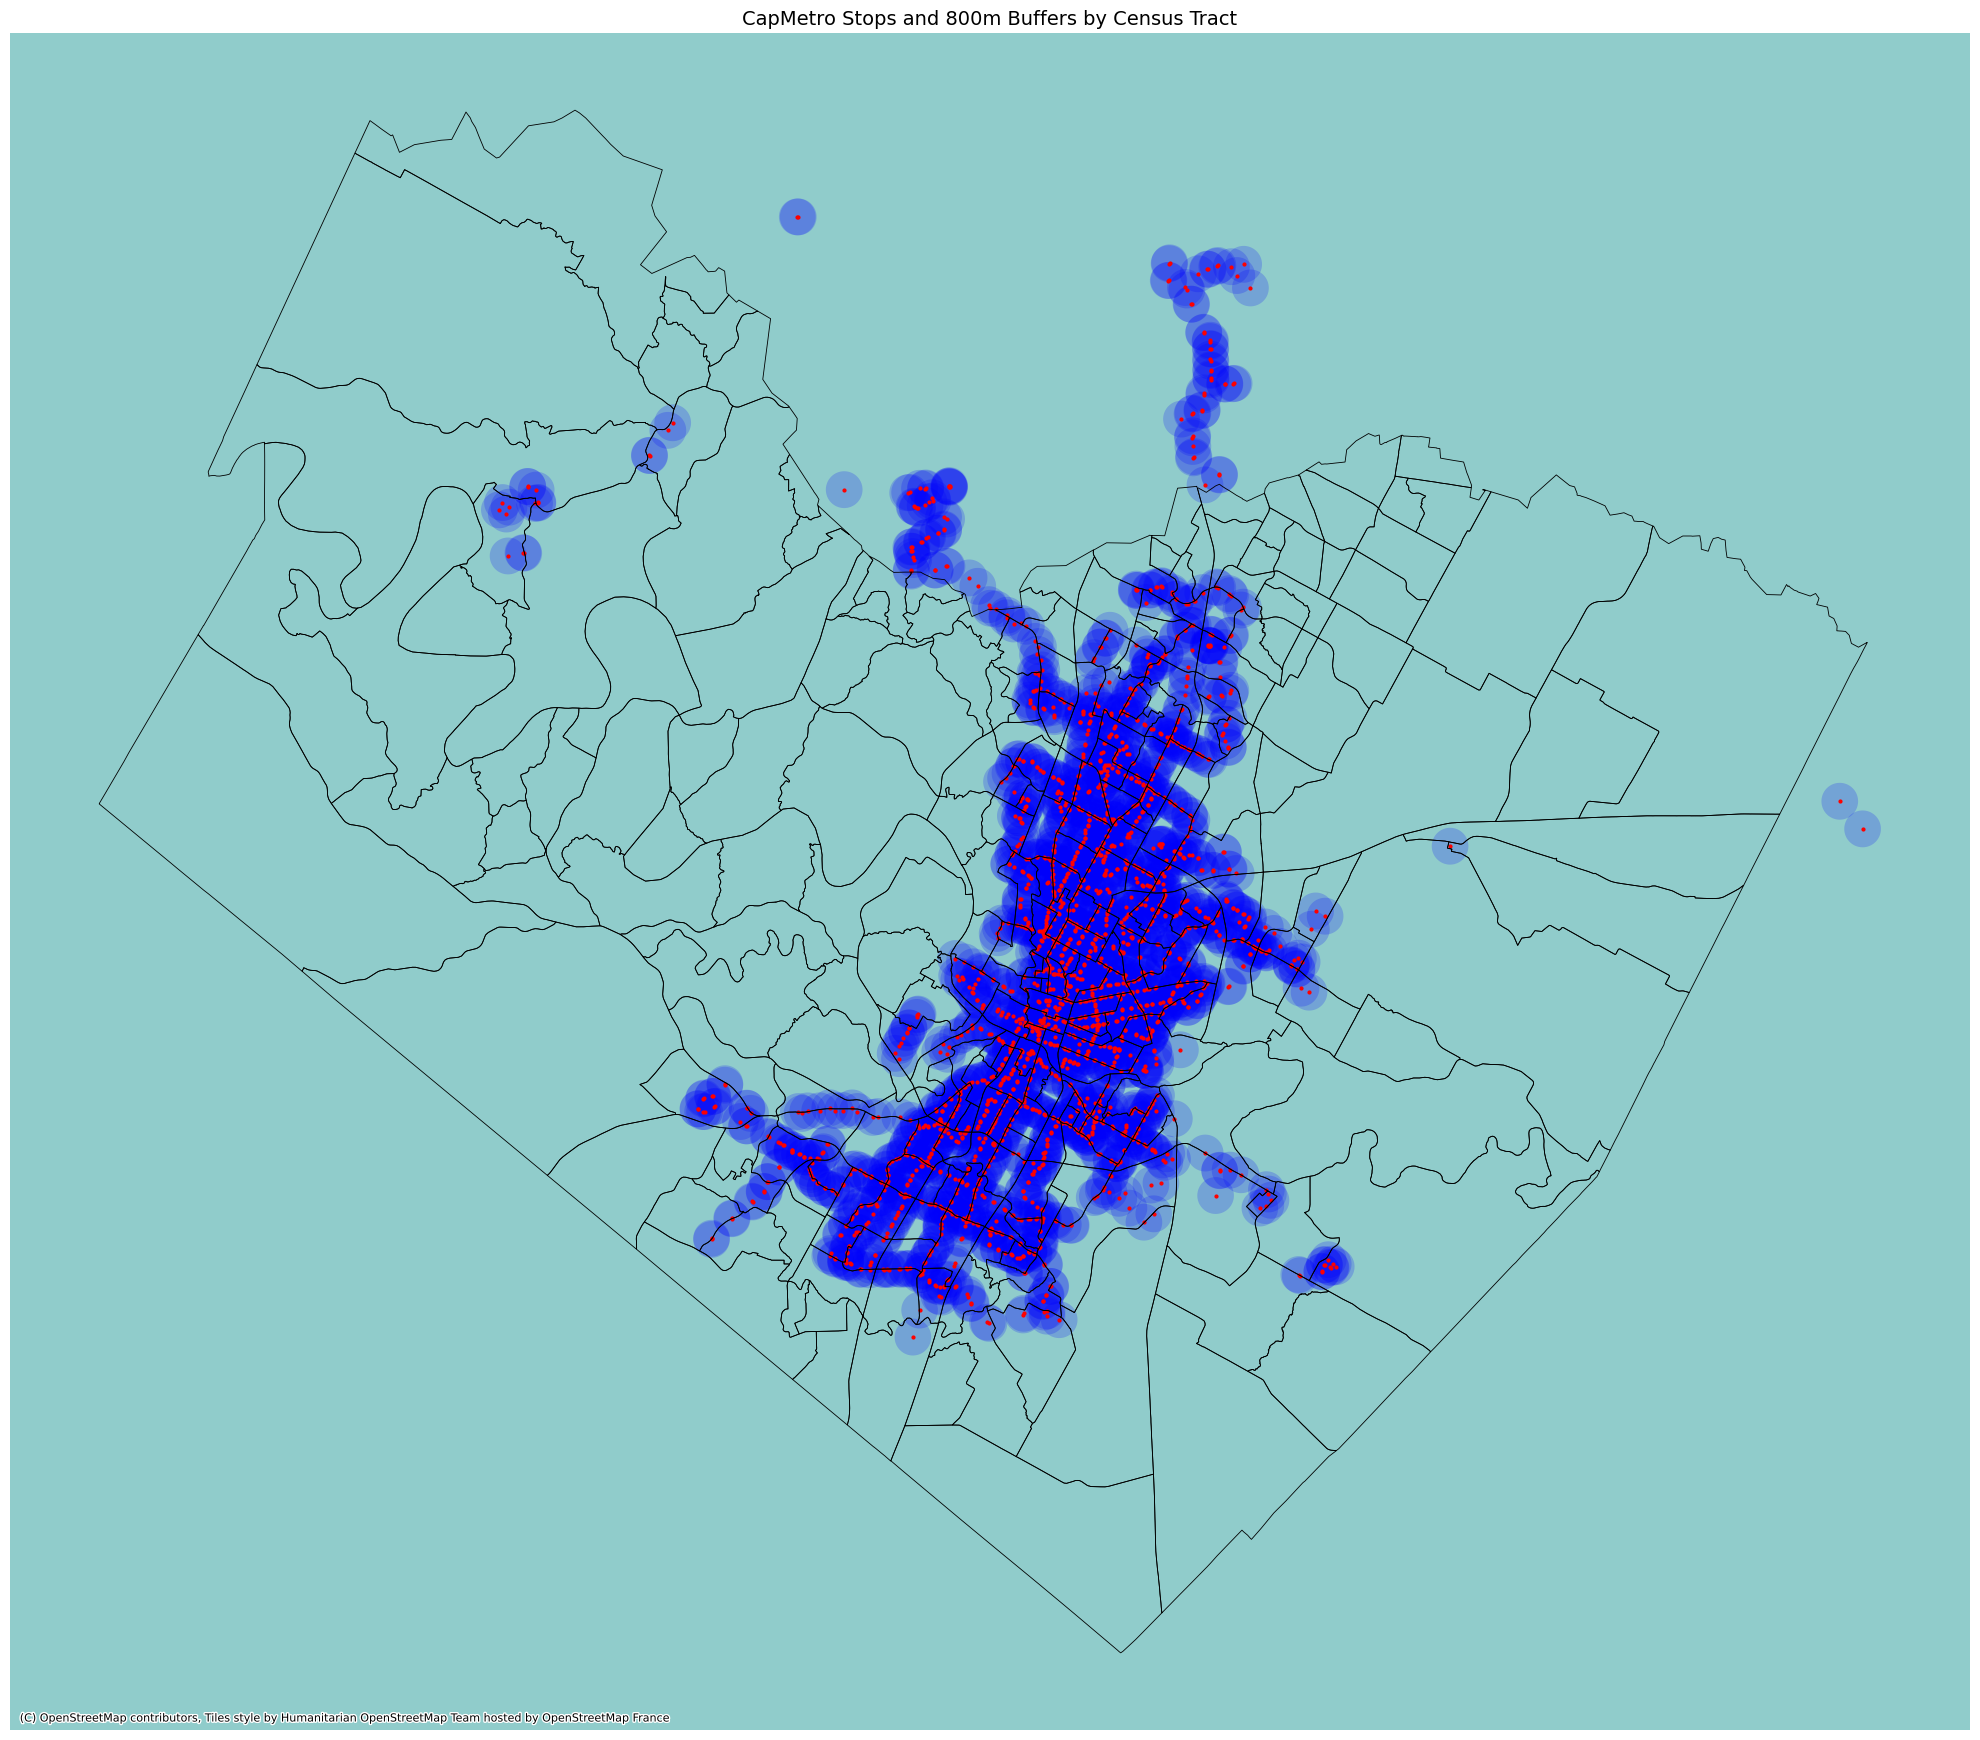

In [52]:
# Map 3: 
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

tracts.boundary.plot(ax=ax, linewidth=0.6, edgecolor="black")
buffers.plot(ax=ax, color="blue", alpha=0.2)
stops.plot(ax=ax, color="red", markersize=4)

ctx.add_basemap(ax)
ax.set_title("CapMetro Stops and 800m Buffers by Census Tract", fontsize=14)
ax.axis("off")
plt.savefig("Map3_CapMetro_Stops.png", dpi=300, bbox_inches='tight')
plt.show()

In [53]:
# MAP 4 — Interactive Map
tracts_wgs = tracts.to_crs(epsg=4326)
stops_wgs = stops.to_crs(epsg=4326)

m = folium.Map(location=[30.27, -97.74], zoom_start=11)

folium.Choropleth(
    geo_data=tracts_wgs,
    data=tracts_wgs,
    columns=["GEOID", "WAccess"],
    key_on="feature.properties.GEOID",
    fill_color="RdYlGn_r",
    fill_opacity=0.5,
    line_opacity=0.2,
    legend_name="Transit Accessibility"
).add_to(m)

for _, row in stops_wgs.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        popup="Bus Stop"
    ).add_to(m)

m.save("Map4_Interactive.html")

In [54]:
m